In [27]:
import os
import sys
import json

sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf

from src.networks.DecoderPINN import PINN
from src.networks.Encoder import Encoder
from src.hyperparameters import hypers_uqvae as h
from src.data.dataloader import load_vae_inference_data
from src.visualization.pdeplots import N_GRID
from src.visualization.uqplots import propagate_and_plot_uncertainty, plot_posterior_ellipse

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.keras.backend.set_floatx('float64')
number_type = tf.float64

np.random.seed(42)
tf.random.set_seed(42)

with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

In [28]:
# decoder (PINN)
U_SCALE = float(np.load('data/models/u_scale_var.npy')[0])
decoder_pinn = PINN(h.N_NEURONS_DECODER, U_SCALE)
decoder_pinn(tf.zeros((1, 4), dtype=number_type))
decoder_pinn.load_weights(f'data/models/weights/{pipeline_id}_decoder_lbfgs.weights.h5')
decoder_pinn.trainable = False

# encoder
encoder_vae = Encoder(n_neurons=h.N_NEURONS_ENCODER, latent_dim=h.D_z)
encoder_vae(tf.zeros((1, h.N_SENSORS), dtype=number_type))
encoder_vae.load_weights(f'data/models/weights/{pipeline_id}_encoder_adam.weights.h5')

# test con sensori usati nel training 
y_test, u_test, X_obs, sensor_idx, _ = load_vae_inference_data(
    data_path='data/fem/fem_parametric_test_grid.npz',
    scale_path='data/models/u_scale_var.npy',
    sensor_idx_path='data/models/sensor_idx.npy',
    n_grid=N_GRID,
    dtype=number_type
)

U_SCALE (loaded): 0.07060286428244116
Shape y_val: (101, 500)  |  Shape u_val: (101, 2)


Calcolo distribuzioni a posteriori


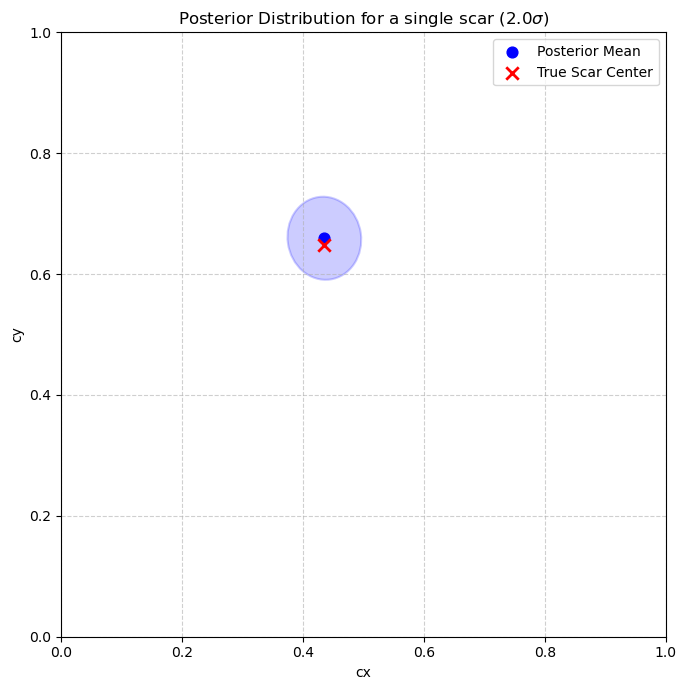

In [31]:
print("Calcolo distribuzioni a posteriori")
qz_test = encoder_vae(y_test)
u_pred_mean = qz_test.mean().numpy()
u_pred_cov = qz_test.covariance().numpy()

sample_idx = 1  # CAMPIONE DA VISUALIZZARE, MODIFICABILE
plot_posterior_ellipse(u_pred_mean, u_pred_cov, u_test.numpy(), sample_idx=sample_idx, n_std=2.0)

Propagazione incertezza per il campione 1 (True cx=0.435, cy=0.648)...


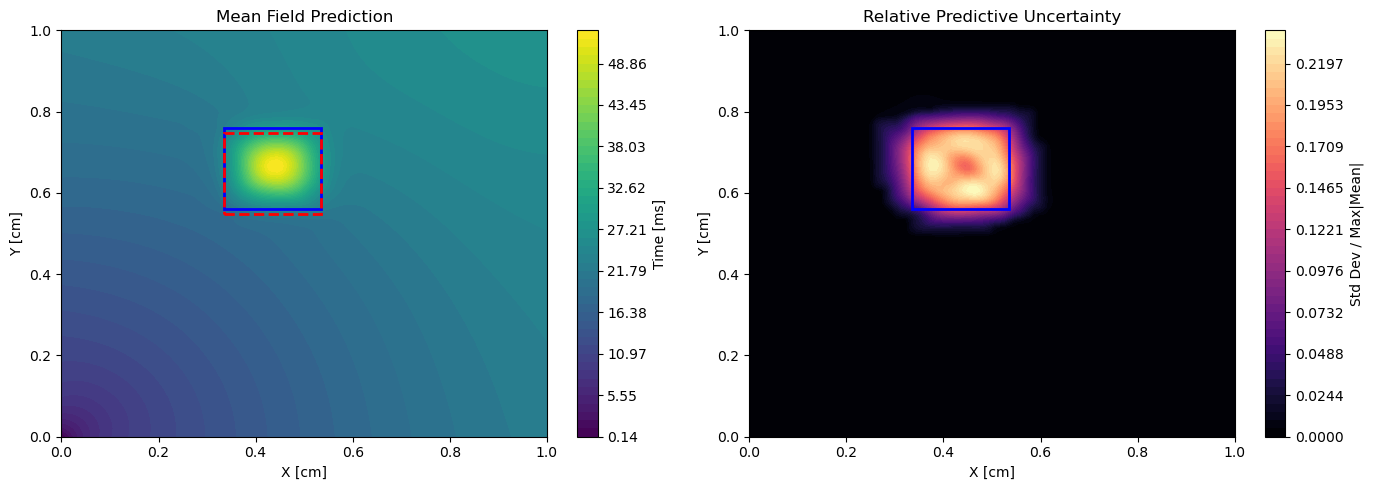

In [32]:
sample_idx = 1  # MODIFICA PER VEDERE ALTRI CAMPIONI

mean_field, std_field, relative_std_field = propagate_and_plot_uncertainty(
    decoder_pinn=decoder_pinn,
    qz_val=qz_test,
    u_pred_mean=u_pred_mean,
    u_true=u_test,
    sample_idx=sample_idx,
    U_SCALE=U_SCALE,
    K_samples=100,
    N_fem=N_GRID,
    lato_cicatrice=0.2,
    number_type=number_type
)

In [ ]:
# prova